In [91]:
# =========================================================
# 3-1. Google Drive 연결 + 기본데이터 확인
# =========================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

file_path = '/content/drive/MyDrive/smartphone_dataset_1M.csv'

df = pd.read_csv(file_path)

print("데이터 크기:")
print(df.shape)

print("\n컬럼 정보:")
print(df.info())

print("\n기초 통계:")
print(df.describe())

print("\n결측치 개수:")
print(df.isnull().sum())

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
데이터 크기:
(1000000, 33)

컬럼 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 33 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   brand                 1000000 non-null  object 
 1   model_name            1000000 non-null  object 
 2   os                    1000000 non-null  object 
 3   price_inr             1000000 non-null  int64  
 4   launch_year           1000000 non-null  int64  
 5   5g_support            1000000 non-null  int64  
 6   dual_sim              1000000 non-null  int64  
 7   expandable_storage    1000000 non-null  int64  
 8   water_resistance      1000000 non-null  int64  
 9   wireless_charging     1000000 non-null  int64  
 10  fingerprint_sensor    1000000 non-null  int64  
 11  face_unlock           1000000 non-n

,brand,model_name,os,price_inr,launch_year,5g_support,dual_sim,expandable_storage,water_resistance,wireless_charging,...,display_size_inch,display_type,refresh_rate_hz,battery_mah,fast_charging_w,rear_camera_mp,front_camera_mp,camera_setup,weight_g,thickness_mm
0,Google,Google_2528,Android,71511,2020,1,1,0,0,1,...,6.10,AMOLED,120,4657,25,200,16,Wide,175.2,8.29
1,Samsung,Samsung_9006,Android,57511,2018,1,0,1,0,0,...,5.77,LCD,120,3817,65,50,8,"Telephoto, Wide",175.6,7.41
2,Google,Google_2059,Android,76042,2022,0,1,1,1,0,...,6.10,LCD,90,5069,25,200,32,"Wide, Ultra-Wide",184.0,8.89
3,Realme,Realme_5737,Android,26916,2021,0,1,0,1,0,...,6.28,AMOLED,60,4323,45,50,8,"Macro, Wide, Telephoto, Depth",173.6,7.67
4,OnePlus,OnePlus_5548,Android,31505,2022,1,0,0,0,1,...,6.45,AMOLED,60,6497,25,50,16,"Depth, Macro, Telephoto, Wide",197.9,9.41


In [92]:
# =========================================================
# 3-2. 중복 제거
# =========================================================

print("전체 중복 개수:")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("\n중복 제거 후 shape:")
print(df.shape)

# 모델명 기준 중복 확인

if 'model_name' in df.columns:
    print("\nmodel_name 중복 개수:")
    print(df['model_name'].duplicated().sum())

전체 중복 개수:
0

중복 제거 후 shape:
(1000000, 33)

model_name 중복 개수:
910010


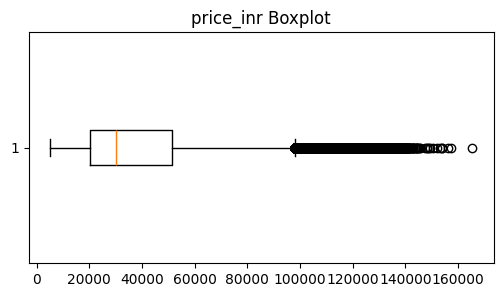

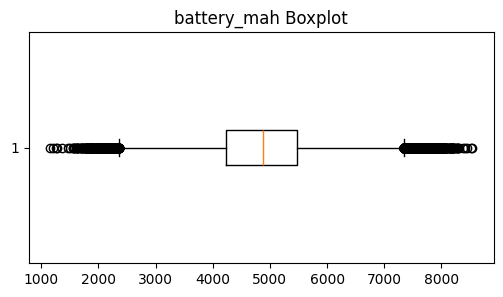

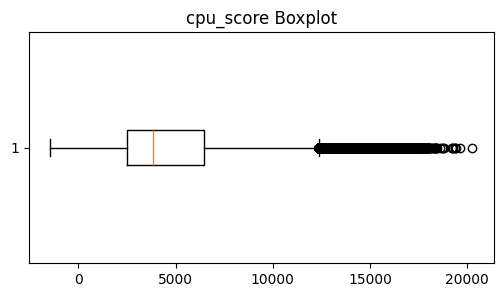

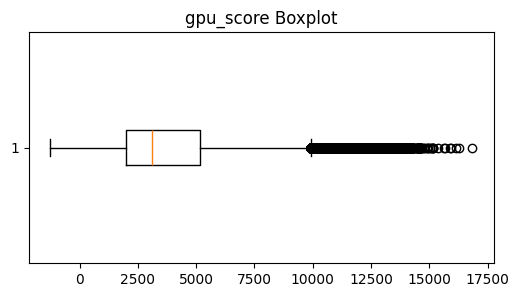

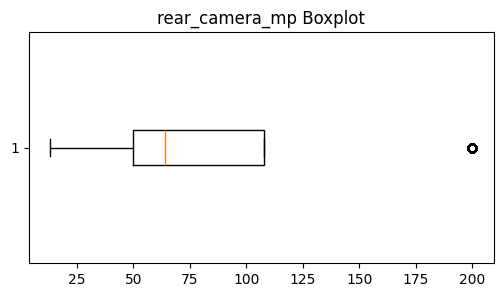

In [93]:
# =========================================================
# 3-3. 이상치 탐지
# =========================================================


import matplotlib.pyplot as plt

# 이상치 확인할 컬럼
outlier_cols = [
    'price_inr',
    'battery_mah',
    'cpu_score',
    'gpu_score',
    'rear_camera_mp'
]


# Boxplot 시각화
for col in outlier_cols:

    plt.figure(figsize=(6,3))

    plt.boxplot(df[col].dropna(), vert=False)

    plt.title(f'{col} Boxplot')

    plt.show()

In [94]:
# =========================================================
# IQR 방식 이상치 탐지 함수
# =========================================================

def detect_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    print(f'{column} 이상치 개수:', len(outliers))

    return outliers

# price 이상치 확인
price_outliers = detect_outliers_iqr(df, 'price_inr')

price_inr 이상치 개수: 30775


In [95]:
# =========================================================
# 3-3. 이상치 탐지
# =========================================================

import numpy as np

# 가격 로그 변환
df['log_price'] = np.log1p(df['price_inr'])

print(df[['price_inr', 'log_price']].head())

   price_inr  log_price
0      71511  11.177621
1      57511  10.959749
2      76042  11.239054
3      26916  10.200513
4      31505  10.357933


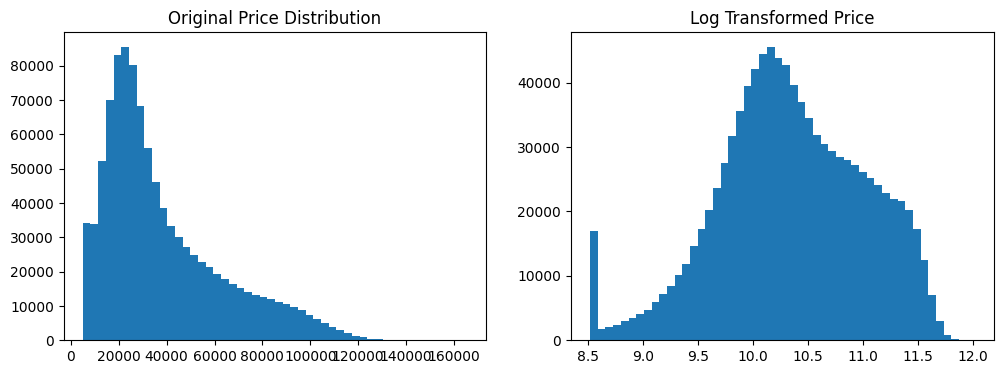

In [96]:
#로그변환 전후 비교
plt.figure(figsize=(12,4))

# 원본 가격 분포
plt.subplot(1,2,1)
plt.hist(df['price_inr'], bins=50)
plt.title('Original Price Distribution')

# 로그 변환 후
plt.subplot(1,2,2)
plt.hist(df['log_price'], bins=50)
plt.title('Log Transformed Price')

plt.show()

In [98]:
# =========================================================
# 3-5. 범주형 인코딩(원핫 인코딩)
# =========================================================

onehot_cols = [
    'brand',
    'os',
    'display_type',
    'build_material',
    'wifi_version',
    'camera_setup'
]

# 실제 존재하는 컬럼만 선택
onehot_cols = [
    col for col in onehot_cols
    if col in df.columns
]

# =========================================================
# One-Hot Encoding 수행
# =========================================================

df = pd.get_dummies(
    df,
    columns=onehot_cols,
    drop_first=True
)

print("One-Hot Encoding 완료")

print("\n현재 shape:")
print(df.shape)

One-Hot Encoding 완료

현재 shape:
(1000000, 248)


In [99]:
# =========================================================
# 3-5. 범주형 인코딩(라벨 인코딩)
# =========================================================

from sklearn.preprocessing import LabelEncoder

label_cols = [
    'chipset',
    'model_name'
]

# =========================================================
# Label Encoding 수행
# =========================================================

for col in label_cols:

    if col in df.columns:

        le = LabelEncoder()

        df[col] = le.fit_transform(
            df[col].astype(str)
        )

print("Label Encoding 완료")

# =========================================================
# object 타입 최종 확인
# =========================================================

object_cols = df.select_dtypes(
    include='object'
).columns

print("\n남은 문자열(object) 컬럼 개수:")
print(len(object_cols))

print("\n남은 문자열 컬럼 목록:")
print(object_cols)

Label Encoding 완료

남은 문자열(object) 컬럼 개수:
0

남은 문자열 컬럼 목록:
Index([], dtype='object')


In [101]:
# =========================================================
# 4-1. 성능 대비 가격 피처(파생피처1)
# =========================================================

# CPU 가성비
df['cpu_per_price'] = (
    df['cpu_score'] / df['price_inr']
)


# GPU 가성비
df['gpu_per_price'] = (
    df['gpu_score'] / df['price_inr']
)


# 배터리 가성비
df['battery_per_price'] = (
    df['battery_mah'] / df['price_inr']
)


# 카메라 가성비
df['camera_per_price'] = (
    (
        df['rear_camera_mp'] +
        df['front_camera_mp']
    ) / df['price_inr']
)

print("가성비 Feature 생성 완료")

가성비 Feature 생성 완료


In [102]:
# =========================================================
# 4-2. 종합 성능 점수 피처(파생피처2)
# =========================================================

# 성능 점수
df['performance_score'] = (
    df['cpu_score'] * 0.6 +
    df['gpu_score'] * 0.4
)


# 멀티미디어 점수
df['multimedia_score'] = (
    df['refresh_rate_hz'] * 0.3 +
    df['rear_camera_mp'] * 0.4 +
    df['battery_mah'] * 0.3
)

print("종합 점수 Feature 생성 완료")

종합 점수 Feature 생성 완료


In [103]:
# =========================================================
# 4-3. 프리미엄 기능(아래 설정한 기능) 개수 피처(파생피처3)
# =========================================================
premium_cols = [
    '5g_support',
    'wireless_charging',
    'water_resistance',
    'face_unlock'
]

premium_cols = [
    col for col in premium_cols
    if col in df.columns
]

df['premium_feature_count'] = (
    df[premium_cols].sum(axis=1)
)

print(df['premium_feature_count'].head())

0    3
1    2
2    1
3    2
4    3
Name: premium_feature_count, dtype: int64


In [104]:
# =========================================================
# 4-4. 휴대성 점수 피처(파생피처4)
# =========================================================
df['portability_score'] = (
    df['weight_g'] * 0.5 +
    df['thickness_mm'] * 0.5
)

print("휴대성 점수 생성 완료")

휴대성 점수 생성 완료


In [105]:
# =========================================================
# 4-5. 디스플레이 품질 점수 피처(파생피처5)
# =========================================================
df['display_quality_score'] = (
    df['refresh_rate_hz'] * 0.5 +
    df['screen_to_body_ratio'] * 0.5
)

print("디스플레이 점수 생성 완료")

디스플레이 점수 생성 완료


In [106]:
# =========================================================
# 4-6. 저장효율 피처(파생피처6)
# =========================================================
df['storage_efficiency'] = (
    df['storage_gb'] / df['price_inr']
)

print("저장 효율 Feature 생성 완료")

저장 효율 Feature 생성 완료


In [107]:
# =========================================================
# 4-7. 프랜드 프리미엄 피처(파생피처7)
# 이 피처는 원핫 전 생성함
# =========================================================

brand_cols = [
    col for col in df.columns
    if col.startswith('brand_')
]

print("브랜드 컬럼 개수:", len(brand_cols))

def recover_brand(row):

    for col in brand_cols:

        if row[col] == 1:

            return col.replace('brand_', '')

    # drop_first=True 때문에
    # 모든 값이 0인 경우 기준 브랜드

    return 'Base_Brand'

df['brand_name'] = df.apply(
    recover_brand,
    axis=1
)


# 브랜드별 평균 가격 계산
brand_avg_price = (
    df.groupby('brand_name')['price_inr']
    .mean()
)


# 브랜드 프리미엄 Feature 생성
df['brand_avg_price'] = (
    df['brand_name']
    .map(brand_avg_price)
)


# 브랜드 프리미엄 지수
# (브랜드 평균 가격 / 전체 평균 가격)
overall_avg_price = df['price_inr'].mean()

df['brand_premium_score'] = (
    df['brand_avg_price'] / overall_avg_price
)


# 결과
print(df[
    [
        'brand_name',
        'brand_avg_price',
        'brand_premium_score'
    ]
].head())

브랜드 컬럼 개수: 9
  brand_name  brand_avg_price  brand_premium_score
0     Google     59989.899143             1.564011
1    Samsung     50093.546175             1.306001
2     Google     59989.899143             1.564011
3     Realme     18141.918048             0.472982
4    OnePlus     40001.682890             1.042893


In [108]:
#모델링 전에 4-7 관련해서 문자열 제거
df = df.drop(columns=['brand_name'])

In [109]:
# =========================================================
# 4-8. 최신 피처(파생피처8)
# =========================================================
current_year = 2026

if 'launch_year' in df.columns:

    df['phone_age'] = (
        current_year - df['launch_year']
    )

print("최신성 Feature 생성 완료")

최신성 Feature 생성 완료


In [110]:
# =========================================================
# 4-9. 전체 가성비 피처(파생피처9)
# =========================================================
df['value_score'] = (
    (
        df['performance_score'] * 0.4 +
        df['battery_mah'] * 0.2 +
        df['rear_camera_mp'] * 0.2 +
        df['refresh_rate_hz'] * 0.2
    ) / df['price_inr']
)

print(df[['value_score']].head())

   value_score
0     0.058756
1     0.061195
2     0.058169
3     0.090838
4     0.094140


In [111]:
#segment 확인
segment_features = [
    'price_inr',
    'performance_score',
    'battery_mah',
    'rear_camera_mp',
    'refresh_rate_hz',
    'premium_feature_count'
]

segment_features = [
    col for col in segment_features
    if col in df.columns
]

segment_df = df[segment_features]

segment_df.head()

,price_inr,performance_score,battery_mah,rear_camera_mp,refresh_rate_hz,premium_feature_count
0,71511,8015.8,4657,200,120,3
1,57511,6805.0,3817,50,120,2
2,76042,8378.8,5069,200,90,1
3,26916,3896.0,4323,50,60,2
4,31505,4111.2,6497,50,60,3


In [64]:
#이런식으로...?

# 예산 입력
budget = 30000


# 예산 이하 스마트폰 필터링
filtered = df[
    df['price_inr'] <= budget
]


# 가성비 기준 정렬
recommend = filtered.sort_values(
    'value_score',
    ascending=False
)


# TOP 10 추천
recommend[
    ['price_inr', 'value_score']
].head(10)

,price_inr,value_score
606572,5000,0.431968
24773,5000,0.410904
979884,5000,0.410280
114468,5000,0.409024
127284,5000,0.405816
913906,5000,0.397128
656564,5000,0.395944
516230,5000,0.392704
952965,5000,0.387392
534677,5000,0.387144


In [112]:
# =========================================================
# 3-6.스케일링(standard scaling)
# =========================================================
from sklearn.preprocessing import StandardScaler

scale_cols = [
    'cpu_score',
    'gpu_score',
    'battery_mah',
    'refresh_rate_hz',
    'rear_camera_mp'
]


scale_cols = [col for col in scale_cols if col in df.columns]


# Standard Scaling
scaler = StandardScaler()

df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("Scaling 완료")

Scaling 완료


In [113]:
# =========================================================
# 전처리 완료 데이터 저장
# =========================================================

save_path = '/content/drive/MyDrive/smartphone_processed(except regression).csv'

df.to_csv(save_path, index=False)

print("저장 완료:", save_path)

저장 완료: /content/drive/MyDrive/smartphone_processed(except regression).csv


In [114]:
# =========================================================
# 회귀 모델용 CSV 생성
# =========================================================

# 회귀 모델에서 제외할 컬럼


leakage_cols = [
    'cpu_per_price',
    'gpu_per_price',
    'battery_per_price',
    'camera_per_price',
    'storage_efficiency',
    'value_score'
]


leakage_cols = [
    col for col in leakage_cols
    if col in df.columns
]

# 회귀 모델용 데이터 생성
regression_df = df.drop(
    columns=leakage_cols
)


# 문자열 컬럼 제거
object_cols = regression_df.select_dtypes(
    include='object'
).columns

regression_df = regression_df.drop(
    columns=object_cols
)

print("회귀 모델용 데이터 shape:")
print(regression_df.shape)


save_path = '/content/drive/MyDrive/smartphone_processed(regression).csv'

regression_df.to_csv(
    save_path,
    index=False
)

print("\n저장 완료:")
print(save_path)

회귀 모델용 데이터 shape:
(1000000, 256)

저장 완료:
/content/drive/MyDrive/smartphone_processed(regression).csv
